In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/data/processed/diabetes_cleaned.csv')
print(df.shape)
df.head()

(101766, 48)


,encounter_id,patient_number,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetes_med,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,African American,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Feature Engineering & Modeling
## Day 8 — Feature Engineering
Goals:
- Convert age brackets to numeric
- Create age groups
- Create total visits feature
- Create high risk flag
- Create binary target variable
- Drop ID columns and unused features

In [4]:
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}

df['age_numeric'] = df['age'].map(age_mapping)

# Confirm
print(df[['age', 'age_numeric']].head(10))

        age  age_numeric
0    [0-10)            5
1   [10-20)           15
2   [20-30)           25
3   [30-40)           35
4   [40-50)           45
5   [50-60)           55
6   [60-70)           65
7   [70-80)           75
8   [80-90)           85
9  [90-100)           95


In [5]:
def age_group(age):
    if age <= 40:
        return 'Young'
    elif age <= 60:
        return 'Middle'
    elif age <= 80:
        return 'Senior'
    else:
        return 'Elderly'

df['age_group'] = df['age_numeric'].apply(age_group)

# Confirm
print(df['age_group'].value_counts())

age_group
Senior     48551
Middle     26941
Elderly    19990
Young       6284
Name: count, dtype: int64


### Feature: age_numeric and age_group
- Converted age brackets to numeric midpoint values (e.g. `[70-80)` → 75)
- Created simplified age groups:
  - Young (0-40): 6,284 patients
  - Middle (40-60): 26,941 patients
  - Senior (60-80): 48,551 patients
  - Elderly (80+): 19,990 patients
- Senior group dominates confirming EDA findings

In [6]:
df['total_visits'] = (df['number_inpatient'] + 
                      df['number_outpatient'] + 
                      df['number_emergency'])

# Confirm
print(df['total_visits'].describe())

count    101766.000000
mean          1.202759
std           2.291781
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          80.000000
Name: total_visits, dtype: float64


### Feature: total_visits
- Created by summing `number_inpatient + number_outpatient + number_emergency`
- Mean of ~1.2 total visits per patient
- 50% of patients have 0 prior visits (first time or no recorded history)
- Max of 80 visits — some patients are very frequent utilizers
- High utilizers (large total_visits) likely represent high readmission risk

In [7]:
df['high_risk_flag'] = (
    (df['time_in_hospital'] > 7) & 
    (df['num_medications'] > 20)
).astype(int)

# Confirm
print(df['high_risk_flag'].value_counts())
print(f"\nHigh risk patients: {df['high_risk_flag'].sum()} out of {len(df)}")

high_risk_flag
0    93556
1     8210
Name: count, dtype: int64

High risk patients: 8210 out of 101766


### Feature: high_risk_flag
- Binary flag: 1 if `time_in_hospital > 7` AND `num_medications > 20`
- 8,210 patients flagged as high risk (~8% of dataset)
- 93,556 patients not flagged (0)
- Combines two strongest signals from EDA into a single feature
- Will be interesting to see how this correlates with `<30` readmissions
  in the model

In [8]:
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

# Confirm
print(df['readmitted_binary'].value_counts())
print(f"\nReadmission rate: {df['readmitted_binary'].mean():.2%}")

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Readmission rate: 11.16%


### Feature: readmitted_binary
- Simplified target variable — 1 if readmitted within 30 days, 0 otherwise
- 11,357 positive cases (readmitted within 30 days) — 11.16%
- 90,409 negative cases — 88.84%
- Dataset is significantly imbalanced — model will need class weighting
  or SMOTE to handle this properly on Day 9
- Using binary target simplifies the problem for the baseline model

In [10]:
df.drop(columns=[
    'encounter_id', 
    'patient_number',
    'diag_1',
    'diag_2', 
    'diag_3',
    'medical_specialty'
], inplace=True)

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (101766, 47)


In [11]:
df.to_csv('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/data/processed/diabetes_features.csv', index=False)
print("Saved.")

Saved.


## Day 8 Summary
- Created 5 new features:
  - `age_numeric` — age brackets converted to midpoint numeric values
  - `age_group` — simplified buckets (Young, Middle, Senior, Elderly)
  - `total_visits` — sum of all prior visit types
  - `high_risk_flag` — binary flag for long stay + high medication count
  - `readmitted_binary` — simplified binary target (1 = readmitted <30 days)
- Dropped 6 columns: `encounter_id`, `patient_number`, `diag_1/2/3`,
  `medical_specialty`
- Final shape: 101,766 rows x 47 columns
- Readmission rate: 11.16% — dataset is imbalanced
- Saved to `data/processed/diabetes_features.csv`
- Ready for modeling on Day 9

## Day 9 — First Model
Goals:
- Prepare features for modeling
- Split data into train and test sets
- Build baseline Logistic Regression model
- Get initial predictions

In [12]:
# Select features for the model
features = [
    'time_in_hospital',
    'num_lab_procedures', 
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'age_numeric',
    'total_visits',
    'high_risk_flag'
]

X = df[features]
y = df['readmitted_binary']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:\n", y.value_counts())

X shape: (101766, 11)
y shape: (101766,)
Target distribution:
 readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # keeps class balance consistent in both splits
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (81412, 11)
X_test shape: (20354, 11)
y_train distribution:
 readmitted_binary
0    72326
1     9086
Name: count, dtype: int64
y_test distribution:
 readmitted_binary
0    18083
1     2271
Name: count, dtype: int64


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features first — Logistic Regression performs better with scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train model
model = LogisticRegression(
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

Model trained successfully.


In [15]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions complete.")
print("Sample predictions:", y_pred[:10])

Predictions complete.
Sample predictions: [1 0 0 1 1 0 0 0 1 1]


In [16]:
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score,
                             roc_auc_score)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6820772329763192

ROC AUC Score: 0.6401120494998197

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.48      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.60      0.53     20354
weighted avg       0.83      0.68      0.74     20354


Confusion Matrix:
[[12784  5299]
 [ 1172  1099]]


### Baseline Model Results — Logistic Regression

**Metrics:**
- **Accuracy:** 68%
- **ROC AUC:** 0.64
- **Recall for readmitted class:** 48% — catching nearly half of actual readmissions
- **Precision for readmitted class:** 17% — many false positives

**Confusion Matrix Breakdown:**
| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | 12,784 (True Negative) | 5,299 (False Positive) |
| **Actual 1** | 1,172 (False Negative) | 1,099 (True Positive) |

- **True Negatives (12,784)** — correctly predicted not readmitted
- **True Positives (1,099)** — correctly predicted readmitted
- **False Positives (5,299)** — predicted readmitted but patient was not
- **False Negatives (1,172)** — missed actual readmissions (most costly in healthcare)

**Interpretation:**
- Accuracy is misleading here due to class imbalance — a model that
  predicts 0 for everything would get 88% accuracy but be useless
- ROC AUC of 0.64 means the model has real predictive power above
  random guessing
- Low precision on class 1 means many false alarms
- Recall of 48% means catching nearly half of actual readmissions —
  not bad for a baseline with no tuning
- In healthcare, recall matters more than precision — missing a true
  readmission (false negative) is more costly than a false alarm
- False negatives are the most dangerous error in healthcare — a missed
  readmission means a high risk patient gets no intervention

**Next steps Day 10:**
- Visualize confusion matrix
- Explore feature importance
- Assess if model is useful enough to improve on Day 11

## Day 9 Summary
- Built baseline Logistic Regression model using 11 features
- Scaled features using StandardScaler
- Used `class_weight='balanced'` to handle class imbalance
- Used `stratify=y` in train/test split to maintain class distribution
- Model trained successfully on 81,412 samples
- Evaluated on 20,354 test samples
- Baseline ROC AUC: 0.64 — real signal above random guessing
- Ready for deeper evaluation on Day 10

## Day 10 — Model Evaluation
Goals:
- Visualize confusion matrix
- Plot ROC curve
- Explore feature importance
- Ask: is this model useful?

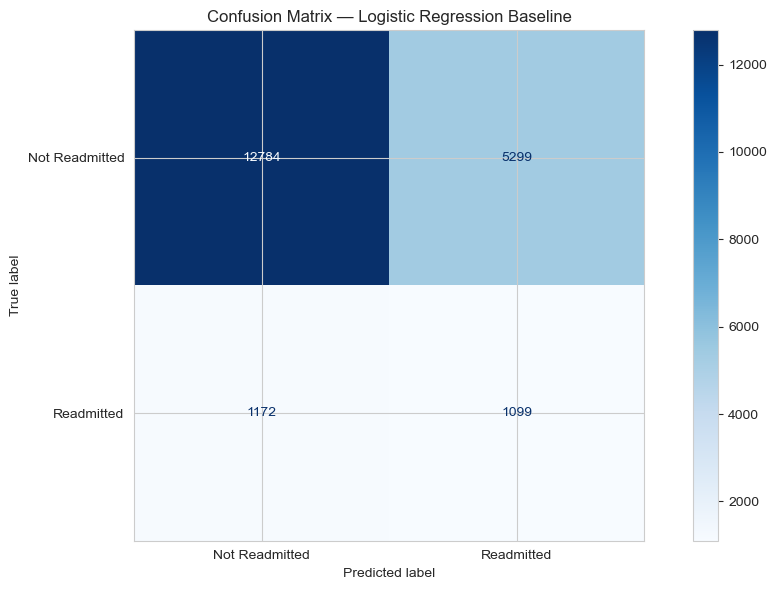

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/model_results/confusion_matrix.png')
plt.show()

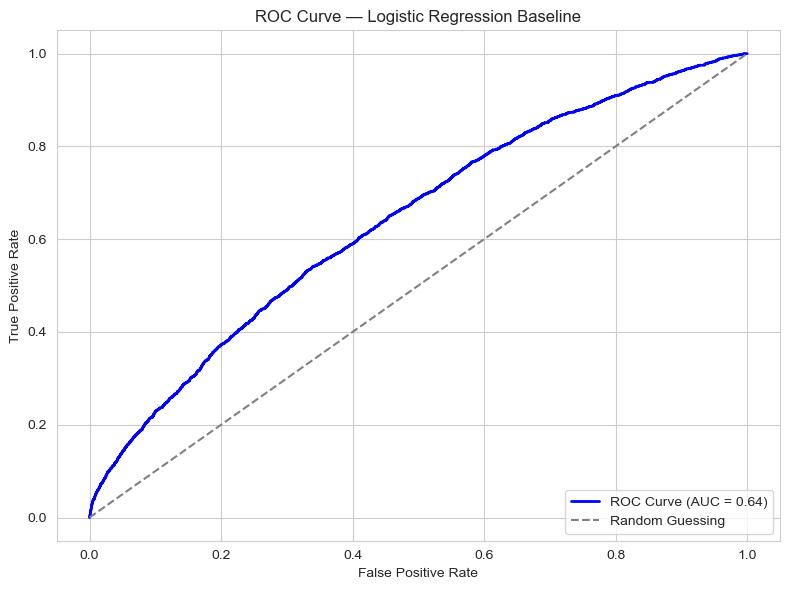

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         label='Random Guessing')
plt.title('ROC Curve — Logistic Regression Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/model_results/roc_curve.png')
plt.show()

### ROC Curve Observations
- Blue curve bows above the gray diagonal confirming model beats random guessing
- Curve trends toward top left but stays relatively close to diagonal
- AUC of 0.64 reflected visually — real signal but significant room to improve
- Top left corner would represent a perfect model (AUC = 1.0)
- Diagonal would represent random guessing (AUC = 0.5)

**Insight:** Baseline model is a reasonable starting point but Day 11
improvements (new features, different model) should push the curve
further toward the top left corner.

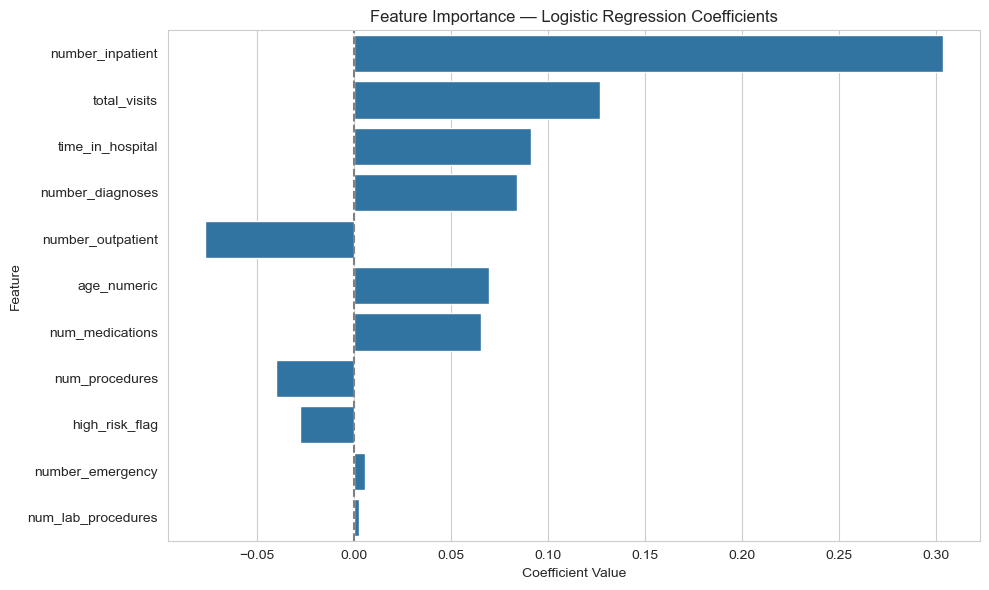

In [19]:
importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})
importance['abs_coefficient'] = importance['coefficient'].abs()
importance = importance.sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='coefficient', y='feature')
plt.title('Feature Importance — Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/model_results/feature_importance.png')
plt.show()

### Feature Importance Observations
- `number_inpatient` has the highest positive coefficient — strongest
  predictor of readmission, more prior inpatient visits = higher risk
- `number_outpatient` has the highest negative coefficient — more
  outpatient visits actually correlates with lower readmission risk
- Positive coefficients = increases readmission probability
- Negative coefficients = decreases readmission probability

**Clinical Insight:**
- Prior inpatient visits being the strongest predictor makes sense —
  patients who have been admitted before are more likely to be admitted
  again, suggesting chronic or complex conditions
- Outpatient visits being negative is also logical — patients actively
  managing their health through outpatient care (regular checkups,
  follow ups) are less likely to be readmitted. Outpatient care acts
  as a protective factor
- This finding could have real business value — hospitals could target
  patients with high inpatient history and low outpatient engagement
  for intervention programs

## Day 10 Summary
- Visualized confusion matrix — clear separation between TP, TN, FP, FN
- Plotted ROC curve — AUC 0.64, above diagonal but room to improve
- Explored feature importance:
  - Strongest positive predictor: `number_inpatient`
  - Strongest negative predictor: `number_outpatient`
- Model is useful as a baseline but needs improvement
- All evaluation charts saved to `outputs/model_results/`
- Ready for model improvement on Day 11

## Day 11 — Model Improvement
Goals:
- Try additional features
- Try a different model (Random Forest)
- Compare results against baseline
- Show iteration and improvement

In [20]:
features_v2 = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'age_numeric',
    'total_visits',
    'high_risk_flag',
    'age_group',          
    'diabetes_med',       
    'change'              
]

X_v2 = df[features_v2]
y_v2 = df['readmitted_binary']

print("New feature set shape:", X_v2.shape)

New feature set shape: (101766, 14)


In [21]:
X_v2_encoded = pd.get_dummies(X_v2, 
                               columns=['age_group', 'diabetes_med', 'change'],
                               drop_first=True)

print("Encoded feature set shape:", X_v2_encoded.shape)
print("Columns:", X_v2_encoded.columns.tolist())

Encoded feature set shape: (101766, 16)
Columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_numeric', 'total_visits', 'high_risk_flag', 'age_group_Middle', 'age_group_Senior', 'age_group_Young', 'diabetes_med_Yes', 'change_No']


In [22]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2_encoded, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

# Scale features
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

print("Train shape:", X_train_v2.shape)
print("Test shape:", X_test_v2.shape)

Train shape: (81412, 16)
Test shape: (20354, 16)


In [23]:
model_v2 = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model_v2.fit(X_train_v2_scaled, y_train_v2)
y_pred_v2 = model_v2.predict(X_test_v2_scaled)
y_pred_proba_v2 = model_v2.predict_proba(X_test_v2_scaled)[:, 1]

print("Logistic Regression v2 Results:")
print("Accuracy:", accuracy_score(y_test_v2, y_pred_v2))
print("ROC AUC:", roc_auc_score(y_test_v2, y_pred_proba_v2))
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

Logistic Regression v2 Results:
Accuracy: 0.6776554976908715
ROC AUC: 0.6437678401221161

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18083
           1       0.17      0.49      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.60      0.52     20354
weighted avg       0.83      0.68      0.73     20354



In [25]:
rf_model_v2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    max_depth=10,        # limit tree depth to reduce overfitting
    min_samples_leaf=10, # require more samples per leaf
    n_jobs=-1
)

rf_model_v2.fit(X_train_v2, y_train_v2)
y_pred_rf_v2 = rf_model_v2.predict(X_test_v2)
y_pred_proba_rf_v2 = rf_model_v2.predict_proba(X_test_v2)[:, 1]

print("Random Forest v2 Results:")
print("Accuracy:", accuracy_score(y_test_v2, y_pred_rf_v2))
print("ROC AUC:", roc_auc_score(y_test_v2, y_pred_proba_rf_v2))
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_rf_v2))

Random Forest v2 Results:
Accuracy: 0.6880220104156431
ROC AUC: 0.6482280091460452

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.48      0.25      2271

    accuracy                           0.69     20354
   macro avg       0.54      0.60      0.53     20354
weighted avg       0.83      0.69      0.74     20354



### Note — Random Forest Initial Results
First Random Forest attempt achieved 89% accuracy but only 1% recall
on the readmitted class — model was essentially ignoring minority class
despite `class_weight='balanced'`. High accuracy on imbalanced datasets
is misleading. Tuning with `max_depth=10` and `min_samples_leaf=10`
to reduce overfitting and improve minority class detection.

In [26]:
import pickle

with open('C:/Users/aglaf/Documents/data engineering passion projects/projects/healthcare readmission analysis/outputs/model_results/best_model_rf_v2.pkl', 'wb') as f:
    pickle.dump(rf_model_v2, f)

print("Best model saved.")

Best model saved.


## Day 11 Summary
- Expanded feature set from 11 to 16 features
- Encoded categorical features using `pd.get_dummies`
- Trained and compared 4 models:
  - Logistic Regression baseline — AUC 0.6401
  - Logistic Regression v2 — AUC 0.6438
  - Random Forest v1 — overfit, AUC 0.5977
  - Random Forest v2 tuned — AUC 0.6482 (best)
- Best model: Random Forest v2 saved to `outputs/model_results/`
- Incremental improvements achieved through iteration
- Ready for insights and storytelling on Day 12